In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
data_dir = './data'
files = [f for f in os.listdir(data_dir) if f.endswith('.npz')]

In [4]:
files

['embedding_heatmap_Qwen_Qwen3-14B-Base.npz',
 'embedding_heatmap_Qwen_Qwen3-1.7B-Base.npz',
 'embedding_heatmap_Qwen_Qwen3-4B-Base.npz',
 'embedding_heatmap_Qwen_Qwen3-8B-Base.npz',
 'embedding_heatmap_Qwen_Qwen3-0.6B-Base.npz']

Files sorted by model size:
     0.6B: embedding_heatmap_Qwen_Qwen3-0.6B-Base.npz
     1.7B: embedding_heatmap_Qwen_Qwen3-1.7B-Base.npz
     4.0B: embedding_heatmap_Qwen_Qwen3-4B-Base.npz
     8.0B: embedding_heatmap_Qwen_Qwen3-8B-Base.npz
    14.0B: embedding_heatmap_Qwen_Qwen3-14B-Base.npz


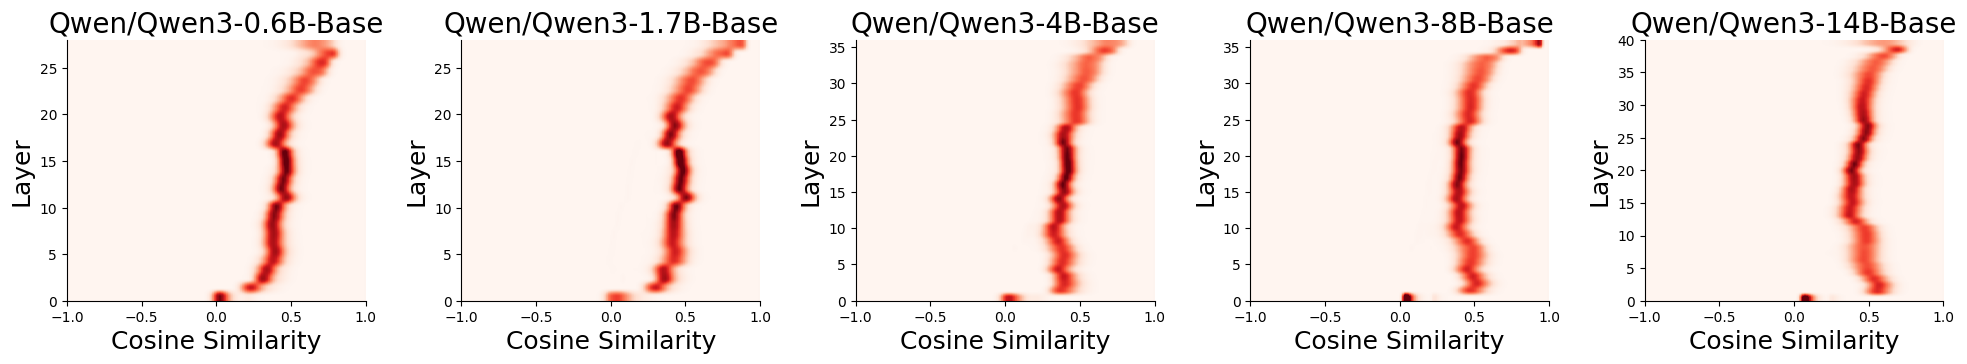

In [20]:
import re

def extract_model_size(filename):
    """Extract model size in billions from filename."""
    # Match patterns like "0.6B", "1.7B", "4B", "8B", "14B", "30B", "32B"
    match = re.search(r'(\d+\.?\d*)B', filename)
    if match:
        return float(match.group(1))
    return float('inf')  # If no match, sort to the end

# Sort files by model size
files_sorted = sorted(files, key=extract_model_size)

print("Files sorted by model size:")
for f in files_sorted:
    print(f"  {extract_model_size(f):6.1f}B: {f}")

# Create figure with subplots in one row
fig = plt.figure(figsize=(4 * len(files_sorted), 4))
vmax = 10

for col_idx, f in enumerate(files_sorted):
    data = np.load(os.path.join(data_dir, f))
    
    # Extract data
    hist_matrix = data['hist_matrix']
    layer_indices = data['layer_indices']
    model_name = str(data['model_name'])
    
    # Create subplot
    ax = fig.add_subplot(1, len(files_sorted), col_idx + 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Plot heatmap
    if hist_matrix.size == 0:
        ax.axis('off')
    else:
        im = ax.imshow(
            hist_matrix,
            aspect='auto',
            origin='lower',
            cmap='Reds',
            extent=[-1, 1, 0, layer_indices[-1]],
            vmin=0,
            vmax=vmax,
        )
    
    # Add labels and title
    ax.set_title(f'{model_name}', fontsize=20)
    ax.set_ylabel('Layer', fontsize=18)
    ax.set_xlabel('Cosine Similarity', fontsize=18)

fig.tight_layout(pad=2)
plt.show()